In [1]:
###Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
from rapidfuzz import process

In [2]:
#clean team names by removing special characters and trimming whitespace
def clean_team_names(df):
    df = df.copy()
    df.rename(columns={df.columns[1]: "Team"}, inplace=True)
    df["Team"] = df["Team"].astype(str).str.replace(r"[*+]", "", regex=True).str.strip() 
    return df

#convert specified columns to numeric, removing percentage signs if present
def numeric_convert(df, cols):
    df = df.copy()
    for col in cols:
        df[col] = pd.to_numeric(df[col].astype(str).str.replace("%",""), errors="coerce")
    return df

#standardize team names in offense dataframe to match those in standings dataframe
def standardize_team_names(df_offense, df_standings):
    standings_teams = df_standings["Team"].tolist()
    df_offense["Team"] = df_offense["Team"].apply(
        lambda x: process.extractOne(x, standings_teams)[0] if x else x
    )
    return df_offense


In [3]:
#load stats from excel
offense = pd.read_excel("data/team_offense_2023.xlsx")
offense = clean_team_names(offense)

# Inspect
print("Offense columns:", offense.columns.tolist())
print(offense.head())
print("Number of rows:", offense.shape[0])


Offense columns: ['Rk', 'Team', 'G', 'Pts', 'Yds', 'Plays', 'Yds/Play', 'TO', 'FumbLost', '1stD', 'Cmp', 'PassAtt', 'PassYds', 'PassTD', 'Int', 'Yds/PassAtt', 'Pass 1stD', 'Rushes', 'RushYds', 'RushTD', 'RushYds/Att', 'Rush1stD', 'Penalties', 'PenYds', '1stDByPen', 'Score%', 'TO%', 'ExpectedPoints']
    Rk                 Team     G    Pts     Yds   Plays  Yds/Play    TO  \
0  1.0       Dallas Cowboys  17.0  509.0  6317.0  1122.0       5.6  16.0   
1  2.0       Miami Dolphins  17.0  496.0  6822.0  1053.0       6.5  25.0   
2  3.0  San Francisco 49ers  17.0  491.0  6773.0  1024.0       6.6  18.0   
3  4.0     Baltimore Ravens  17.0  483.0  6296.0  1076.0       5.9  19.0   
4  5.0        Detroit Lions  17.0  461.0  6712.0  1137.0       5.9  23.0   

   FumbLost   1stD  ...  RushYds  RushTD  RushYds/Att  Rush1stD  Penalties  \
0       6.0  385.0  ...   1920.0    14.0          4.1     113.0      115.0   
1      10.0  360.0  ...   2308.0    27.0          5.1     113.0       97.0   
2       

In [4]:
#choose relevant stats
stats_to_use = [
    "PassYds", "PassTD", "Int", "Yds/PassAtt", "Pass 1stD",
    "RushYds", "RushTD", "RushYds/Att", "Rush1stD",
    "TO", "FumbLost", "Penalties", "PenYds", "1stDByPen",
    "Score%", "TO%", "ExpectedPoints"
]

#make sure that all chosen stats exist in the dataframe
stats_to_use = [c for c in stats_to_use if c in offense.columns]
offense = numeric_convert(offense, stats_to_use) #convert chosen stats to numeric

# Quick test
offense[stats_to_use].head()


,PassYds,PassTD,Int,Yds/PassAtt,Pass 1stD,RushYds,RushTD,RushYds/Att,Rush1stD,TO,FumbLost,Penalties,PenYds,1stDByPen,Score%,TO%,ExpectedPoints
0,4397.0,36.0,10.0,6.7,229.0,1920.0,14.0,4.1,113.0,16.0,6.0,115.0,964.0,43.0,50.3,8.9,192.72
1,4514.0,30.0,15.0,7.6,223.0,2308.0,27.0,5.1,113.0,25.0,10.0,97.0,767.0,24.0,43.5,13.4,128.90
2,4384.0,33.0,12.0,8.4,207.0,2389.0,27.0,4.8,147.0,18.0,6.0,101.0,933.0,29.0,45.3,10.1,268.60
3,3635.0,27.0,7.0,6.8,180.0,2661.0,26.0,4.9,145.0,19.0,12.0,102.0,955.0,35.0,43.1,9.6,138.81
4,4401.0,30.0,12.0,6.9,228.0,2311.0,27.0,4.6,124.0,23.0,11.0,97.0,843.0,23.0,40.6,11.8,191.13


In [5]:
#load in afc and nfc data
afc = pd.read_excel("data/afc_standings_2023.xlsx")
nfc = pd.read_excel("data/nfc_standings_2023.xlsx")

#clean and rename columns
afc = afc.loc[:, ~afc.columns.astype(str).str.contains("Unnamed")]
nfc = nfc.loc[:, ~nfc.columns.astype(str).str.contains("Unnamed")]

afc.rename(columns={afc.columns[0]: "Team"}, inplace=True)
nfc.rename(columns={nfc.columns[0]: "Team"}, inplace=True)

afc["Team"] = afc["Team"].astype(str).str.replace(r"[*+]", "", regex=True).str.strip()
nfc["Team"] = nfc["Team"].astype(str).str.replace(r"[*+]", "", regex=True).str.strip()

#combine afc and nfc dfs
standings = pd.concat([afc, nfc], ignore_index=True)
standings["W"] = pd.to_numeric(standings["W"], errors="coerce")
standings.rename(columns={"W": "Wins"}, inplace=True)

# Inspect
standings.head()


,Team,Wins,L,W-L%,PF,PA,PD,MoV,SoS,SRS,OSRS,DSRS
0,Buffalo Bills,11,6,0.647,451,311,140,8.2,-1.8,6.5,4.1,2.3
1,Miami Dolphins,11,6,0.647,496,391,105,6.2,-1.8,4.4,7.6,-3.1
2,New York Jets,7,10,0.412,268,355,-87,-5.1,-0.6,-5.8,-6.7,0.9
3,New England Patriots,4,13,0.235,236,366,-130,-7.6,-0.2,-7.9,-8.5,0.6
4,Baltimore Ravens,13,4,0.765,483,280,203,11.9,1.2,13.2,6.7,6.5


In [6]:
#merge offense stats with wins from standings
offense = standardize_team_names(offense, standings)
df = offense.merge(standings[["Team", "Wins"]], on="Team", how="inner")

print("Merged dataframe shape:", df.shape)
df.head()


Merged dataframe shape: (35, 29)


,Rk,Team,G,Pts,Yds,Plays,Yds/Play,TO,FumbLost,1stD,...,RushTD,RushYds/Att,Rush1stD,Penalties,PenYds,1stDByPen,Score%,TO%,ExpectedPoints,Wins
0,1.0,Dallas Cowboys,17.0,509.0,6317.0,1122.0,5.6,16.0,6.0,385.0,...,14.0,4.1,113.0,115.0,964.0,43.0,50.3,8.9,192.72,12
1,2.0,Miami Dolphins,17.0,496.0,6822.0,1053.0,6.5,25.0,10.0,360.0,...,27.0,5.1,113.0,97.0,767.0,24.0,43.5,13.4,128.90,11
2,3.0,San Francisco 49ers,17.0,491.0,6773.0,1024.0,6.6,18.0,6.0,383.0,...,27.0,4.8,147.0,101.0,933.0,29.0,45.3,10.1,268.60,12
3,4.0,Baltimore Ravens,17.0,483.0,6296.0,1076.0,5.9,19.0,12.0,360.0,...,26.0,4.9,145.0,102.0,955.0,35.0,43.1,9.6,138.81,13
4,5.0,Detroit Lions,17.0,461.0,6712.0,1137.0,5.9,23.0,11.0,375.0,...,27.0,4.6,124.0,97.0,843.0,23.0,40.6,11.8,191.13,12


In [7]:
#average stats by team in case of multiple entries per team
df_team = df.groupby("Team", as_index=False).mean()

# Test
df_team.head()


,Team,Rk,G,Pts,Yds,Plays,Yds/Play,TO,FumbLost,1stD,...,RushTD,RushYds/Att,Rush1stD,Penalties,PenYds,1stDByPen,Score%,TO%,ExpectedPoints,Wins
0,Arizona Cardinals,24.0,17.0,330.0,5509.0,1068.0,5.2,18.0,6.0,330.0,...,17.0,5.0,127.0,101.0,859.0,30.0,35.0,9.4,-2.99,4.0
1,Atlanta Falcons,26.0,17.0,321.0,5683.0,1092.0,5.2,28.0,11.0,326.0,...,14.0,4.1,121.0,84.0,743.0,24.0,32.1,14.3,-32.52,7.0
2,Baltimore Ravens,4.0,17.0,483.0,6296.0,1076.0,5.9,19.0,12.0,360.0,...,26.0,4.9,145.0,102.0,955.0,35.0,43.1,9.6,138.81,13.0
3,Buffalo Bills,6.0,17.0,451.0,6366.0,1115.0,5.7,28.0,10.0,381.0,...,22.0,4.3,158.0,106.0,883.0,24.0,41.4,14.9,197.57,11.0
4,Carolina Panthers,32.0,17.0,236.0,4510.0,1096.0,4.1,20.0,10.0,297.0,...,7.0,4.0,111.0,103.0,845.0,36.0,25.0,11.1,-135.03,2.0


In [ ]:
#remove constants
numeric_cols = [c for c in stats_to_use if df_team[c].nunique() > 1]
#calculate correlation of each offensive stat with wins, sort descending
correlation = df_team[numeric_cols].corrwith(df_team["Wins"]).sort_values(ascending=False)

print("Correlation of offensive stats with Wins:")
correlation


Correlation of offensive stats with Wins:


Score%            0.762705
Yds/PassAtt       0.759972
ExpectedPoints    0.719595
RushYds/Att       0.221126
RushTD           -0.077212
TO%              -0.099308
PassTD           -0.106004
PassYds          -0.135073
Rush1stD         -0.137779
Pass 1stD        -0.141116
RushYds          -0.141898
PenYds           -0.149007
Penalties        -0.155236
1stDByPen        -0.157367
FumbLost         -0.174761
TO               -0.179641
Int              -0.182209
dtype: float64

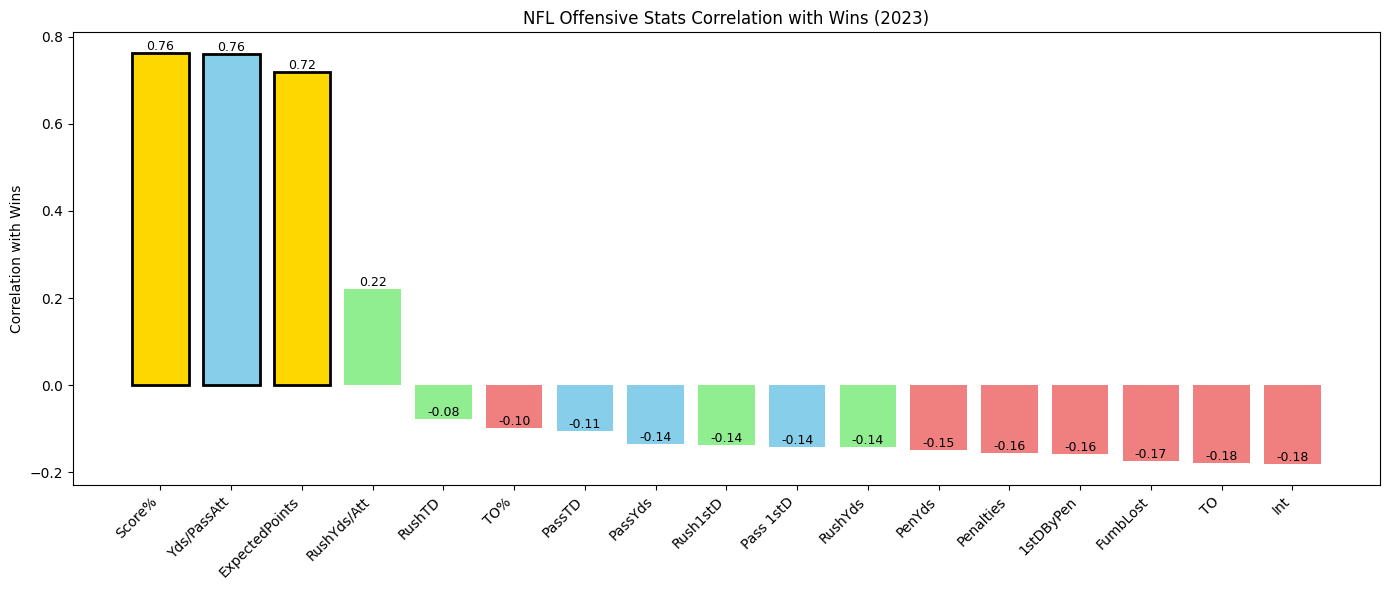

In [ ]:
#visualize correlation results
plt.figure(figsize=(14,6))

#color code based on stat type
colors = []
for stat in correlation.index:
    if "Pass" in stat:
        colors.append("skyblue")
    elif "Rush" in stat:
        colors.append("lightgreen")
    elif stat in ["TO", "FumbLost", "Penalties", "PenYds", "1stDByPen", "Int", "TO%"]:
        colors.append("lightcoral")
    else:
        colors.append("gold")

bars = plt.bar(correlation.index, correlation.values, color=colors)

#highlight top 3 correlated stats
top3_idx = correlation.abs().sort_values(ascending=False).head(3).index
for i, bar in enumerate(bars):
    if correlation.index[i] in top3_idx:
        bar.set_edgecolor("black")
        bar.set_linewidth(2)

#add value labels on to bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height, f"{height:.2f}", ha='center', va='bottom', fontsize=9)

plt.xticks(rotation=45, ha="right")
plt.ylabel("Correlation with Wins")
plt.title("NFL Offensive Stats Correlation with Wins (2023)")
plt.tight_layout()
plt.show()
